# Test Cuantización 

El conjunto de datos **“Fingers”** consiste en una serie de imágenes de 64x64 píxeles con fondo negro donde en su centro se encuentra un mano que muestra una cantidad de dedos que va desde 0 a 5. La versión original de este conjunto de imágenes se encuentra en: https://www.kaggle.com/koryakinp/fingers  


### Características extraidas de la imagen  

Área: 3740.0
Perímetro: 343.49747468305833
Excentricidad: 0.05970895058121077
Solidez: 0.9130859375
Bounding box: (0, 0, 64, 64)
Centroide: (np.float64(31.470320855614972), np.float64(31.55133689839572))
----------------------------------------
Área: 34.0
Perímetro: 23.485281374238568
Excentricidad: 0.9413057228483238
Solidez: 0.723404255319149
Bounding box: (30, 26, 36, 38)
Centroide: (np.float64(32.529411764705884), np.float64(31.058823529411764))
----------------------------------------


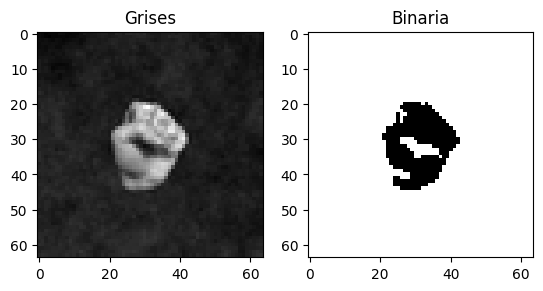

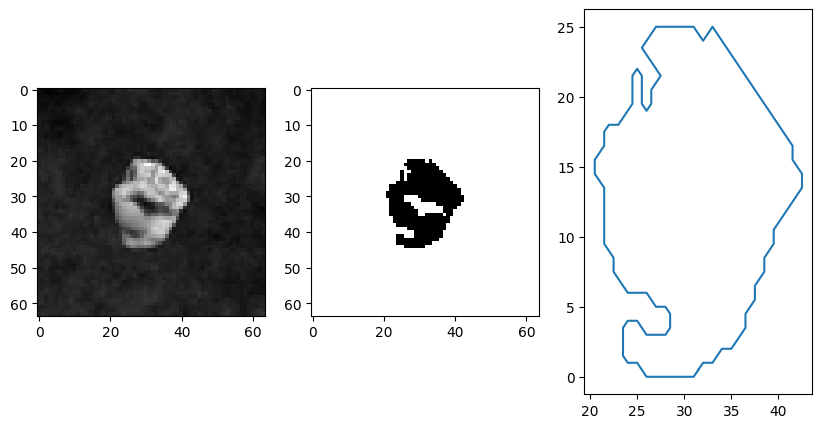

In [17]:
FUENTES_DIR = '../Fuentes'         # carpeta donde se encuentran archivos .py auxiliares
DATOS_DIR   = '../Imagenes/Fingers/' # carpeta donde se encuentran los datasets
import os, glob, math, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.filters import threshold_otsu
from skimage.morphology import closing, footprint_rectangle
from skimage.segmentation import clear_border
from skimage.measure import regionprops, label, find_contours

img = io.imread(DATOS_DIR + "samples/0L.png")
# Si la imagen tiene 4 canales (RGBA), convertir a RGB antes de pasar a escala de grises
if img.shape[-1] == 4:
    img_rgb = img[..., :3]
    gray = color.rgb2gray(img_rgb)
else:
    gray = color.rgb2gray(img) if len(img.shape) == 3 else img

# binarización (umbral automático Otsu)
thresh = threshold_otsu(gray)
binary = gray < thresh  # mano en blanco (1), fondo negro (0)

# etiquetar regiones
label_img = label(binary)

# extraer propiedades
props = regionprops(label_img)

# mostrar algunas propiedades de la primera región
for prop in props:
    print(f"Área: {prop.area}")
    print(f"Perímetro: {prop.perimeter}")
    print(f"Excentricidad: {prop.eccentricity}")
    print(f"Solidez: {prop.solidity}")
    print(f"Bounding box: {prop.bbox}")
    print(f"Centroide: {prop.centroid}")
    print("-" * 40)

# graficar
plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Grises")

plt.subplot(1,2,2)
plt.imshow(binary, cmap="gray")
plt.title("Binaria")
plt.show()

fig, axs = plt.subplots(1,3, figsize=(10,5))
axs[0].imshow(gray, cmap='gray')
axs[1].imshow(binary, cmap='gray')

contour = find_contours(binary, 0.5)[0]
y, x = contour.T

axs[2].plot(x, y.max()-y)


### Test y Train

Script que convierte las imágenes en las carpetas **“test”** y **“train”** del dataset **“Fingers”** en dos archivos (uno por carpeta) separados por comas (csv). De todas las características que provee **regionprops**, tienen potencial aquellas que son independientes o se pueden independizar de las unidades (píxeles). Algunas de estas características pueden ser:  

- **filled_area:** cantidad de píxeles que contiene región (podría interpretarse como píxeles cuadrados).
- **major_axis_length:** longitud (en píxeles) del eje mayor de la elipse que mejor se ajusta a la región.
- **minor_axis_length:** longitud (en píxeles) del eje menor de la elipse que mejor se ajusta a la región.
- **perimeter:** cantidad de píxeles que forman el contorne de la región.
- **eccentricity:** excentricidad de la elipse de mejor ajuste, cerca de 0 es un círculo, mientras que cerca de 1 es una elipse más “larga”.
- **solidity:** razón entre la cantidad de píxeles de la región original y de la región convexa. Para generar una región convexa se completan los pixeles de forma de eliminar regiones cóncavas de una figura. La región convexa de una estrella de 5 puntas se convertirá en un pentágono al completarla.
- **extent:** razón entre pixeles de la región original y el rectángulo que la contiene (bounding box).


In [18]:
import os, glob, math, warnings
import pandas as pd
import numpy as np
from skimage import io
from skimage.filters import threshold_otsu
from skimage.morphology import closing, footprint_rectangle
from skimage.segmentation import clear_border
from skimage.measure import regionprops, label

warnings.filterwarnings("ignore", category=FutureWarning)  # silencia warnings 

from skimage.morphology import footprint_rectangle

def extraer_caracteristicas(imagen):
    umbral = threshold_otsu(imagen)
    imagen_bn = (imagen > umbral)*1
    imagen_bn = closing(imagen_bn, footprint_rectangle((3, 3)))  
    imagen_lista = clear_border(imagen_bn)
    regiones = regionprops(label(imagen_lista))
    return (regiones[0], imagen_lista)


def convertir_dataset(dir_orig, dir_arch_dest):
    columnas = ['AreaNorm', 'PerimNorm', 'RazonEjes', 'Excentricidad', 
                'Solidez', 'Extension', 'CantDedos']

    archivos = glob.glob(os.path.join(dir_orig, '**/*.png'), recursive=True)
    data = []

    total = len(archivos)
    for nro, archivo in enumerate(archivos, start=1):
        if nro % 200 == 0 or nro == total:  # imprime cada 200 imgs, no en todas
            print(f"\rProcesando {nro}/{total} imágenes ({100*nro/total:.2f}%)", end="")

        imagen = io.imread(archivo)
        cant_dedos = int(os.path.basename(os.path.dirname(archivo)))  # nombre carpeta = etiqueta

        props, imagen_bn = extraer_caracteristicas(imagen)

        area = props.filled_area
        ej_mayor = props.major_axis_length
        ej_menor = props.minor_axis_length
        perim = props.perimeter
        excentr = props.eccentricity
        solidez = props.solidity
        extension = props.extent

        # normalización
        area = area / (ej_mayor * ej_menor)
        perim = perim / math.sqrt(ej_mayor * ej_menor)
        razon_ej = ej_menor / ej_mayor

        data.append([area, perim, razon_ej, excentr, solidez, extension, cant_dedos])

    df = pd.DataFrame(columns=columnas, data=data)
    df.to_csv(dir_arch_dest, index=False)
    print(f"\n✅ Guardado en {dir_arch_dest}")

# Uso -> guarda en DeepLearning/Data_Sets/p4/
base_out = "../Data_Sets"

convertir_dataset("../Imagenes/Fingers/train", os.path.join(base_out, "fingers_train.csv"))
convertir_dataset("../Imagenes/Fingers/test",  os.path.join(base_out, "fingers_test.csv"))

Procesando 17999/17999 imágenes (100.00%)
✅ Guardado en ../Data_Sets/fingers_train.csv
Procesando 3600/3600 imágenes (100.00%)
✅ Guardado en ../Data_Sets/fingers_test.csv


## Entrenamiento Modelo Multiperceptrón

Entrenamiento de un modelo de multiperceptrón a partir del archivo de entrenamiento generado en el punto anterior.  


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import preprocessing, metrics, model_selection

from sklearn.model_selection import cross_val_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
import seaborn as sns
DATOS_DIR   = '../Data_Sets/' # carpeta donde se encuentran los datasets
# %% CARGA DE DATASET
nom_archivo = DATOS_DIR + 'fingers_train.csv'
datos = pd.read_csv(nom_archivo)


# separa características y clase
X = np.array(datos.iloc[:, :-1])
Y = np.array(datos.iloc[:, -1])
nomClases = datos.iloc[:, -1].value_counts()

# Target codificado como one-hot
encoder = preprocessing.LabelEncoder()
Y_nro = encoder.fit_transform(Y)
Y_bin= to_categorical(Y_nro)

# %% --- CONJUNTOS DE ENTRENAMIENTO Y VALIDACION ---
X_train, X_val, Y_train, Y_val = model_selection.train_test_split( \
                                         X, Y_bin, test_size=0.20, random_state=42)

normalizador = preprocessing.StandardScaler()
X_train = normalizador.fit_transform(X_train)
X_val = normalizador.transform(X_val)

datos


,AreaNorm,PerimNorm,RazonEjes,Excentricidad,Solidez,Extension,CantDedos
0,0.772097,3.455084,0.679345,0.733819,0.932500,0.690741,0
1,0.747383,3.474195,0.642108,0.766614,0.922849,0.691111,0
2,0.734556,4.203402,0.766965,0.641689,0.892857,0.636364,0
3,0.768645,3.446018,0.730245,0.683185,0.925414,0.670000,0
4,0.774000,3.365307,0.730927,0.682455,0.940510,0.728070,0
...,...,...,...,...,...,...,...
17994,0.551767,5.648539,0.633040,0.774119,0.576408,0.393773,5
17995,0.576778,5.770199,0.699539,0.714595,0.600000,0.371512,5
17996,0.538463,6.011802,0.712541,0.701631,0.555088,0.365854,5
17997,0.605275,5.455247,0.732710,0.680541,0.613725,0.382173,5


### Modelo

In [20]:
ENTRADAS = X_train.shape[1]
SALIDAS = Y_train.shape[1]
OCULTAS = 8
EPOCAS = 200
LOTES = 32
PACIENCIA = 5
ACTIVACION = 'tanh'
OPTIMIZADOR = 'adam'


# %% CONSTRUCCION DEL MODELO
model = Sequential()
model.add(Dense(OCULTAS, input_shape=[ENTRADAS], activation=ACTIVACION))
model.add(Dense(SALIDAS, activation='softmax'))
model.summary()  #-- muestra la cantidad de parámetros de la red


model.compile(optimizer=OPTIMIZADOR, loss='categorical_crossentropy', metrics=['accuracy'])

# %% ENTRENAMIENTO

# parada temprana para evitar el sobreajuste
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=PACIENCIA)

# entrena el modelo y guarda la historia del progreso
history = model.fit(X_train,Y_train, epochs=EPOCAS, batch_size=LOTES, validation_data = (X_val, Y_val), callbacks=[early_stop])

#Guarda el modelo entrenado
model.save('../Models/fingers_model_no_quantization.h5')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110 (440.00 B)

 Trainable params: 110 (440.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5777 - loss: 1.1324 - val_accuracy: 0.7681 - val_loss: 0.8197
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step - accuracy: 0.8091 - loss: 0.6648 - val_accuracy: 0.8344 - val_loss: 0.5524
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.8563 - loss: 0.4773 - val_accuracy: 0.8781 - val_loss: 0.4175
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - accuracy: 0.8951 - loss: 0.3755 - val_accuracy: 0.9119 - val_loss: 0.3338
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.9212 - loss: 0.3067 - val_accuracy: 0.9311 - val_loss: 0.2741
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.9337 - loss: 0.2572 - val_accuracy: 0.9414 - val_loss: 0.2293
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.9434 - loss: 0.2195 - val_accuracy: 0.9522 - val_loss: 0.1957
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9502 - loss: 0.190

## Cuantización Simetrica con signo
Se cuantizan los pesos del modelo usando int8 y se guardan dos versiones, una por capa, y otra por neurona. Por otro lado tambien se cuantizan las entradas y salidas de los modelos. Finalmente se realiza una comparación de metricas entre los mismos.

In [21]:
import os
import io
import warnings
import logging
import contextlib

# Silenciar logs/warnings de TensorFlow/absl antes de importar TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
from absl import logging as absl_logging
from sklearn import metrics

# Silenciar logs adicionales en runtime
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
absl_logging.set_verbosity(absl_logging.ERROR)


# Cuantización simétrica con signo (signed symmetric)
# Rango entero: [-Qmax, Qmax], con Qmax = 2^(bits-1)-1
# int8: [-127, 127]


def quantize_symmetric_signed(x, bits=8, axis=None, eps=1e-12):
    qmax = (2 ** (bits - 1)) - 1

    if axis is None:
        max_abs = np.max(np.abs(x))
    else:
        max_abs = np.max(np.abs(x), axis=axis, keepdims=True)

    scale = np.where(max_abs < eps, 1.0, max_abs / qmax)
    q = np.round(x / scale)
    q = np.clip(q, -qmax, qmax).astype(np.int32)
    dq = (q.astype(np.float32) * scale).astype(np.float32)
    return q, dq, scale


def quantize_dense_weights_symmetric(model, bits=8, mode='per_layer'):
    # mode: 'per_layer' o 'per_neuron'
    q_model = tf.keras.models.clone_model(model)
    q_model.build(model.input_shape)

    new_weights = []
    for w in model.get_weights():
        if mode == 'per_layer':
            _, w_dq, _ = quantize_symmetric_signed(w, bits=bits, axis=None)
        elif mode == 'per_neuron':
            # Para Dense kernel shape=(in, out): una escala por neurona de salida (por columna)
            if w.ndim == 2:
                _, w_dq, _ = quantize_symmetric_signed(w, bits=bits, axis=0)
            else:
                # Bias u otros tensores 1D: por elemento
                _, w_dq, _ = quantize_symmetric_signed(w, bits=bits, axis=0)
        else:
            raise ValueError("mode debe ser 'per_layer' o 'per_neuron'")

        new_weights.append(w_dq)

    q_model.set_weights(new_weights)
    q_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return q_model


def evaluate_pipeline_io_dequantized(model_to_eval, X_eval, Y_eval, bits_io=8):
    # 1) Cuantizar entradas y dequantizar para inferencia
    _, X_qdq, _ = quantize_symmetric_signed(X_eval.astype(np.float32), bits=bits_io, axis=None)

    # 2) Inferencia
    y_pred_float = model_to_eval.predict(X_qdq, verbose=0)

    # 3) Cuantizar salidas y dequantizar antes de clasificar
    _, y_pred_qdq, _ = quantize_symmetric_signed(y_pred_float.astype(np.float32), bits=bits_io, axis=None)

    y_true = np.argmax(Y_eval, axis=1)
    y_pred = np.argmax(y_pred_qdq, axis=1)

    return {
        'accuracy': metrics.accuracy_score(y_true, y_pred),
        'f1_macro': metrics.f1_score(y_true, y_pred, average='macro'),
        'report': metrics.classification_report(y_true, y_pred, digits=4),
        'cm': metrics.confusion_matrix(y_true, y_pred)
    }


def evaluate_pipeline_io_quantized(model_to_eval, X_eval, Y_eval, bits_io=8):
    # 1) Cuantizar entradas y usar enteros (cast a float para que Keras pueda inferir)
    q_x, _, _ = quantize_symmetric_signed(X_eval.astype(np.float32), bits=bits_io, axis=None)
    x_for_model = q_x.astype(np.float32)

    # 2) Inferencia con entradas cuantizadas
    y_pred_float = model_to_eval.predict(x_for_model, verbose=0)

    # 3) Cuantizar salidas y clasificar con enteros (sin dequantizar)
    q_y, _, _ = quantize_symmetric_signed(y_pred_float.astype(np.float32), bits=bits_io, axis=None)

    y_true = np.argmax(Y_eval, axis=1)
    y_pred = np.argmax(q_y.astype(np.float32), axis=1)

    return {
        'accuracy': metrics.accuracy_score(y_true, y_pred),
        'f1_macro': metrics.f1_score(y_true, y_pred, average='macro'),
        'report': metrics.classification_report(y_true, y_pred, digits=4),
        'cm': metrics.confusion_matrix(y_true, y_pred)
    }


# Baseline (sin cuantizar) para comparación

def evaluate_baseline(model_to_eval, X_eval, Y_eval):
    y_pred_float = model_to_eval.predict(X_eval, verbose=0)
    y_true = np.argmax(Y_eval, axis=1)
    y_pred = np.argmax(y_pred_float, axis=1)

    return {
        'accuracy': metrics.accuracy_score(y_true, y_pred),
        'f1_macro': metrics.f1_score(y_true, y_pred, average='macro'),
        'report': metrics.classification_report(y_true, y_pred, digits=4),
        'cm': metrics.confusion_matrix(y_true, y_pred)
    }


def export_full_int8_tflite(model_to_convert, output_path, x_reference, max_samples=500):
    converter = tf.lite.TFLiteConverter.from_keras_model(model_to_convert)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    x_reference = x_reference.astype(np.float32)

    def representative_dataset():
        n = min(max_samples, x_reference.shape[0])
        for i in range(n):
            yield [x_reference[i:i+1]]

    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    # Silencia salida verbosa del conversor (incluye stderr nativo C++)
    stderr_fd = os.dup(2)
    devnull_fd = os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull_fd, 2)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            tflite_model = converter.convert()
    finally:
        os.dup2(stderr_fd, 2)
        os.close(stderr_fd)
        os.close(devnull_fd)

    with open(output_path, 'wb') as f:
        f.write(tflite_model)


# Carga modelo base y evalúa variantes
BASE_MODEL_PATH = '../Models/fingers_model_no_quantization.h5'
BITS_W = 8
BITS_IO = 8

base_model = tf.keras.models.load_model(BASE_MODEL_PATH)

# 1) Baseline
res_base_train = evaluate_baseline(base_model, X_train.astype(np.float32), Y_train)
res_base_val = evaluate_baseline(base_model, X_val.astype(np.float32), Y_val)

# 2) Cuantización de pesos por capa
model_q_layer = quantize_dense_weights_symmetric(base_model, bits=BITS_W, mode='per_layer')

res_q_layer_train_io_dq = evaluate_pipeline_io_dequantized(model_q_layer, X_train, Y_train, bits_io=BITS_IO)
res_q_layer_val_io_dq = evaluate_pipeline_io_dequantized(model_q_layer, X_val, Y_val, bits_io=BITS_IO)

res_q_layer_train_io_q = evaluate_pipeline_io_quantized(model_q_layer, X_train, Y_train, bits_io=BITS_IO)
res_q_layer_val_io_q = evaluate_pipeline_io_quantized(model_q_layer, X_val, Y_val, bits_io=BITS_IO)

# 3) Cuantización de pesos por neurona
model_q_neuron = quantize_dense_weights_symmetric(base_model, bits=BITS_W, mode='per_neuron')

res_q_neuron_train_io_dq = evaluate_pipeline_io_dequantized(model_q_neuron, X_train, Y_train, bits_io=BITS_IO)
res_q_neuron_val_io_dq = evaluate_pipeline_io_dequantized(model_q_neuron, X_val, Y_val, bits_io=BITS_IO)

res_q_neuron_train_io_q = evaluate_pipeline_io_quantized(model_q_neuron, X_train, Y_train, bits_io=BITS_IO)
res_q_neuron_val_io_q = evaluate_pipeline_io_quantized(model_q_neuron, X_val, Y_val, bits_io=BITS_IO)


# Tabla comparativa: ambos casos (I/O dequantizado y I/O cuantizado)
comparison = pd.DataFrame([
    {
        'Modelo': 'Baseline (sin cuantización)',
        'Pipeline': 'float',
        'Split': 'Train',
        'Accuracy': res_base_train['accuracy'],
        'F1_macro': res_base_train['f1_macro']
    },
    {
        'Modelo': 'Baseline (sin cuantización)',
        'Pipeline': 'float',
        'Split': 'Val',
        'Accuracy': res_base_val['accuracy'],
        'F1_macro': res_base_val['f1_macro']
    },
    {
        'Modelo': 'Q simétrica signed (pesos por capa)',
        'Pipeline': 'in/out dequantized',
        'Split': 'Train',
        'Accuracy': res_q_layer_train_io_dq['accuracy'],
        'F1_macro': res_q_layer_train_io_dq['f1_macro']
    },
    {
        'Modelo': 'Q simétrica signed (pesos por capa)',
        'Pipeline': 'in/out dequantized',
        'Split': 'Val',
        'Accuracy': res_q_layer_val_io_dq['accuracy'],
        'F1_macro': res_q_layer_val_io_dq['f1_macro']
    },
    {
        'Modelo': 'Q simétrica signed (pesos por capa)',
        'Pipeline': 'in/out quantized',
        'Split': 'Train',
        'Accuracy': res_q_layer_train_io_q['accuracy'],
        'F1_macro': res_q_layer_train_io_q['f1_macro']
    },
    {
        'Modelo': 'Q simétrica signed (pesos por capa)',
        'Pipeline': 'in/out quantized',
        'Split': 'Val',
        'Accuracy': res_q_layer_val_io_q['accuracy'],
        'F1_macro': res_q_layer_val_io_q['f1_macro']
    },
    {
        'Modelo': 'Q simétrica signed (pesos por neurona)',
        'Pipeline': 'in/out dequantized',
        'Split': 'Train',
        'Accuracy': res_q_neuron_train_io_dq['accuracy'],
        'F1_macro': res_q_neuron_train_io_dq['f1_macro']
    },
    {
        'Modelo': 'Q simétrica signed (pesos por neurona)',
        'Pipeline': 'in/out dequantized',
        'Split': 'Val',
        'Accuracy': res_q_neuron_val_io_dq['accuracy'],
        'F1_macro': res_q_neuron_val_io_dq['f1_macro']
    },
    {
        'Modelo': 'Q simétrica signed (pesos por neurona)',
        'Pipeline': 'in/out quantized',
        'Split': 'Train',
        'Accuracy': res_q_neuron_train_io_q['accuracy'],
        'F1_macro': res_q_neuron_train_io_q['f1_macro']
    },
    {
        'Modelo': 'Q simétrica signed (pesos por neurona)',
        'Pipeline': 'in/out quantized',
        'Split': 'Val',
        'Accuracy': res_q_neuron_val_io_q['accuracy'],
        'F1_macro': res_q_neuron_val_io_q['f1_macro']
    }
])

pd.set_option('display.float_format', lambda x: f'{x:.6f}')
print('\nComparación de métricas\n')
print(comparison)

print('\n' + '=' * 90)
print('Reporte VAL - Pesos por capa - in/out dequantized')
print(res_q_layer_val_io_dq['report'])

print('\n' + '=' * 90)
print('Reporte VAL - Pesos por capa - in/out quantized')
print(res_q_layer_val_io_q['report'])

print('\n' + '=' * 90)
print('Reporte VAL - Pesos por neurona - in/out dequantized')
print(res_q_neuron_val_io_dq['report'])

print('\n' + '=' * 90)
print('Reporte VAL - Pesos por neurona - in/out quantized')
print(res_q_neuron_val_io_q['report'])

# Guardar comparación para informe
comparison.to_csv('../Data_Sets/quantization_comparison_signed_symmetric.csv', index=False)
print('\nSe guardó: ../Data_Sets/quantization_comparison_signed_symmetric.csv')

# Guardar modelos reales int8 (pesos y operaciones int8) en TFLite
export_full_int8_tflite(model_q_layer, '../Models/fingers_model_q_signed_symmetric_per_layer_int8.tflite', X_train)
export_full_int8_tflite(model_q_neuron, '../Models/fingers_model_q_signed_symmetric_per_neuron_int8.tflite', X_train)
print('Se guardaron modelos INT8 reales en ../Models/ (*.tflite)')


Comparación de métricas

                                   Modelo            Pipeline  Split  \
0             Baseline (sin cuantización)               float  Train   
1             Baseline (sin cuantización)               float    Val   
2     Q simétrica signed (pesos por capa)  in/out dequantized  Train   
3     Q simétrica signed (pesos por capa)  in/out dequantized    Val   
4     Q simétrica signed (pesos por capa)    in/out quantized  Train   
5     Q simétrica signed (pesos por capa)    in/out quantized    Val   
6  Q simétrica signed (pesos por neurona)  in/out dequantized  Train   
7  Q simétrica signed (pesos por neurona)  in/out dequantized    Val   
8  Q simétrica signed (pesos por neurona)    in/out quantized  Train   
9  Q simétrica signed (pesos por neurona)    in/out quantized    Val   

   Accuracy  F1_macro  
0  0.994166  0.994134  
1  0.995278  0.995384  
2  0.993888  0.993854  
3  0.995556  0.995652  
4  0.635669  0.549424  
5  0.632778  0.549146  
6  0.994027  

## Explicación de las funciones de cuantización

### 1. `quantize_symmetric_signed(x, bits=8, axis=None, eps=1e-12)`

Convierte valores float a enteros simétricos con signo, luego los dequantiza de vuelta a float. Retorna tres cosas: enteros cuantizados `q`, floats dequantizados `dq`, y la escala.

**Matemática:**
- $q_{max} = 2^{(bits-1)} - 1$
- Para int8, $q_{max} = 127$, rango representable: $[-127, 127]$ (simétrico, sin usar -128)
- Escala: $scale = \frac{\max(|x|)}{q_{max}}$ (o por eje si se especifica)
- Cuantización: $q = round\left(\frac{x}{scale}\right)$ con $q \in [-q_{max}, q_{max}]$
- Dequantización: $dq = q \cdot scale$

**Paso a paso:**
1. Computa $q_{max}$ desde `bits`
2. Encuentra valor absoluto máximo globalmente (si `axis=None`) o por eje
3. Usa `eps` como guarda: si el máximo es muy pequeño, `scale = 1.0` para evitar división por cero
4. Redondea $x/scale$, clipea al rango simétrico, convierte a int32
5. Multiplica por scale para obtener `dq` en float32
6. Retorna `q`, `dq`, `scale`

---

### 2. `quantize_dense_weights_symmetric(model, bits=8, mode='per_layer')`

Crea una copia de un modelo Keras donde cada tensor de peso es reemplazado por su versión dequantizada. Dos modos: `per_layer` y `per_neuron`.

**Paso a paso:**
1. `clone_model` crea la misma arquitectura
2. `build(model.input_shape)` inicializa el modelo clonado
3. Itera sobre todos los tensores de `model.get_weights()`
4. Si `per_layer`: una escala para todo el tensor (axis=None)
5. Si `per_neuron`: 
   - Para kernels 2D de Dense (shape: entrada, salida), usa axis=0 para que cada neurona de salida/columna tenga su propia escala
   - Para tensores 1D como bias, también usa axis=0
6. Añade tensor dequantizado a `new_weights`
7. Asigna estos pesos al modelo clonado
8. Compila el modelo y lo retorna

**Nota importante:** El modelo retornado aún usa operaciones float en Keras. El efecto de cuantización se emula mediante pesos que fueron cuantizados y luego dequantizados.

---

### 3. `evaluate_pipeline_io_dequantized(model_to_eval, X_eval, Y_eval, bits_io=8)`

Evalúa un modelo después de cuantizar y luego dequantizar entradas y salidas. Simula ruido de cuantización manteniendo la ruta de inferencia en float.

**Paso a paso:**
1. Cuantiza $X_{eval}$ e inmediatamente dequantiza: $X_{qdq}$
2. Predice con el modelo en $X_{qdq}$
3. Cuantiza y dequantiza predicciones a $y_{pred-qdq}$
4. Convierte etiquetas one-hot a IDs de clase vía argmax
5. Convierte predicciones a IDs de clase vía argmax
6. Calcula accuracy, F1 macro, reporte de clasificación, matriz de confusión
7. Retorna estos métricas en un diccionario

**Nota:** Este es el camino más cercano al comportamiento de "fake quantization" (inferencia float con efectos de cuantización alrededor).

---

### 4. `evaluate_pipeline_io_quantized(model_to_eval, X_eval, Y_eval, bits_io=8)`

Evalúa con entradas similares a enteros cuantizados y salidas cuantizadas para decisión. Aún usa inferencia float internamente porque el modelo Keras espera tensores float.

**Paso a paso:**
1. Cuantiza entradas a $q_x$
2. Convierte $q_x$ a float32 y alimenta el modelo
3. Cuantiza salidas del modelo a $q_y$ (sin dequantizar para clasificación)
4. Aplica argmax en $q_y$ (convertido a float32) para clase predicha
5. Calcula el mismo diccionario de métricas que arriba

**Nota:** No es inferencia entera verdadera; datos con valores enteros pasan por operaciones Keras en float.

---

### 5. `evaluate_baseline(model_to_eval, X_eval, Y_eval)`

Evaluación estándar en float sin cuantización.

**Paso a paso:**
1. Predice directamente en $X_{eval}$
2. Argmax sobre etiquetas verdaderas y probabilidades predichas
3. Calcula y retorna el mismo diccionario de métricas

**Propósito:** Referencia para comparar variantes cuantizadas contra el comportamiento del modelo original.

---

### 6. `export_full_int8_tflite(model_to_convert, output_path, x_reference, max_samples=500)`

Convierte un modelo Keras a modelo TFLite completamente cuantizado int8 y lo escribe a disco.

**Paso a paso:**
1. Crea conversor desde modelo Keras
2. Habilita optimización por defecto
3. Convierte datos de referencia a float32
4. Construye generador de dataset representativo desde hasta `max_samples` muestras
5. Asigna `representative_dataset` para que el conversor calibre rangos de activaciones
6. Fuerza operaciones solo int8:
   - `supported_ops = TFLITE_BUILTINS_INT8`
   - `inference_input_type = int8`
   - `inference_output_type = int8`
7. Redirige stderr/stdout temporalmente para suprimir logs del conversor
8. Ejecuta `converter.convert()`
9. Restaura stderr y cierra file descriptors seguramente en `finally`
10. Escribe bytes binarios .tflite a `output_path`

**Nota importante:** Esta es la función que produce un artefacto real de despliegue int8, a diferencia de los auxiliares de evaluación que emulaban mayormente efectos de cuantización en ejecución float.

---

### Pipeline completo

1. Modelo baseline se carga y evalúa con `evaluate_baseline`
2. Dos variantes de modelo con pesos cuantizados se construyen con `quantize_dense_weights_symmetric`:
   - `per_layer`
   - `per_neuron`
3. Cada variante se evalúa con:
   - `evaluate_pipeline_io_dequantized`
   - `evaluate_pipeline_io_quantized`
4. Métricas se comparan en una tabla
5. Modelos int8 finales desplegables se exportan con `export_full_int8_tflite`